In [12]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

from freeze_thaw.config import config as c
from freeze_thaw.config import StationName
from freeze_thaw.data_preparation.splitting import collect_process_split
from freeze_thaw.modeling.lgb_train import train_model
from freeze_thaw.modeling.lgb_test import lgb_pred

# Model Development

The goal is to train a lightGBM model and determine the optimal set of lagged features, as well as apply statistical tests to determine if using the optimal set of lagged features outperfoms a model trained without lagged features. Models are trained using time series cross-validation on 80% of the data.

---

## Table of Contents

1. **Setup**
    - *1.1 Variables*
    - *1.2 Functions*
2. **Training and Evaluation**
3. **Results**
    - 3.1 Without Lagged Features
    - 3.2 With Lagged Features
4. **Statistical Analysis**

---

## 1. Setup

### 1.1 Variables

In [6]:
lags_test = [1, 2, 3, 5, 7, 10, 15, 20, 30]
label_map = {
    c.CLASSES[0]: 0,
    c.CLASSES[1]: 1,
    c.CLASSES[2]: 2,
}
train_size = 0.8
n_splits = 5

### 1.2 Functions

In [3]:
def pipeline(stations: type[StationName],
             label_map: dict[str, int],
             n_splits: int,
             train_size: float,
             lagged_features: bool = False,
             lags: list[int] | None = None) -> (pd.DataFrame, pd.DataFrame):
    """
    Train lgbm models for all stations using time series cross-validation then predict on test, with results
    for the train and test sets collected in separate dfs. The train results are for the out-of-fold (OOF) predictions.
    :param stations: StationName class from config.py
    :param label_map: mapping of c.CLASSES to int labels
    :param n_splits: number of folds for cross-validation
    :param train_size: decimal fraction size of training data
    :param lagged_features: create lagged features or not
    :param lags: list of lags e.g. [1, 3] will create features for the backscatter from one and three datapoints prior
    :return: result_train_df and result_test_df
    """
    result_train_df = pd.DataFrame(columns=["Station", "OOF Macro F1", "OOF Transition F1"])
    result_test_df = pd.DataFrame(columns=["Station", "Macro F1", "Transition F1"])

    for station in stations:
        print(f"\nStation: {station}")
        train, test = collect_process_split(station,
                                            c.CLEANED_DATA_PATH,
                                            c.DATETIMEINDEX_NAME,
                                            c.ISMN_LONG_VAR_NAME,
                                            c.ASCAT_KEY_COLS,
                                            c.ERA5_KEY_COLS,
                                            train_size,
                                            label_map,
                                            lagged_features,
                                            lags)

        # train and evaluate model
        train_result = train_model(train, n_splits, label_map)

        # log train results
        result_train_df.loc[len(result_train_df)] = [station, train_result.oof_macro_f1, train_result.oof_transition_f1]

        # predict on test
        test_result = lgb_pred(test, model=train_result.model, label_encoding=label_map)

        # log test results
        result_test_df.loc[len(result_test_df)] = [station, test_result.macro_f1, test_result.transition_f1]

    return result_train_df, result_test_df

def optimal_lag_config_pipeline(stations: type[StationName],
                                label_map: dict[str, int],
                                n_splits: int,
                                train_size: float,
                                lags: list[int]) -> pd.DataFrame:
    """
    Trains lgbm models for all stations and lag configurations using time series cross-validation. For example, if given
    lags=[1, 2, 3], it will train three models for each set of stations with the following lags: [1], [1, 2], and [1, 2, 3].
    :param stations: StationName class from config.py
    :param label_map: mapping of c.CLASSES to int labels
    :param n_splits: number of folds for cross-validation
    :param train_size: decimal fraction size of training data
    :param lags: list of lags
    :return: average OOF metrics for all stations for each lag configuration as a pd.DataFrame. For example,
    given lags=[1, 2, 3], the df will contain three records.
    """
    # average OOF F1 is for all stations for one set of lags i.e. 10 stations results in one score.
    result_df = pd.DataFrame(columns=["Max Lag", "Average OOF Macro F1", "Average OOF Transition F1"])

    for i in range(len(lags)):
        subset = lags[0:i+1]
        max_lag = lags[i]
        print(f"Lag configuration: {subset}")

        intermediate_results = pd.DataFrame(columns=["OOF Macro F1", "OOF Transition F1"])
        for station in stations:
            print(f"    Station: {station}")
            train, _ = collect_process_split(station,
                                                c.CLEANED_DATA_PATH,
                                                c.DATETIMEINDEX_NAME,
                                                c.ISMN_LONG_VAR_NAME,
                                                c.ASCAT_KEY_COLS,
                                                c.ERA5_KEY_COLS,
                                                train_size,
                                                label_map,
                                                True,
                                                subset)

            # train and evaluate model
            train_result = train_model(train, n_splits, label_map)

            # log train results
            intermediate_results.loc[len(intermediate_results)] = [train_result.oof_macro_f1, train_result.oof_transition_f1]

        result_df.loc[i] = [max_lag, intermediate_results["OOF Macro F1"].mean(), intermediate_results["OOF Transition F1"].mean()]

    return result_df

## 2. Determine Optimal Lag Configuration

In [7]:
lag_config_results = optimal_lag_config_pipeline(StationName, label_map, n_splits, train_size, lags_test)

Lag configuration: [1]
    Station: Aberdeen-35-WNW
    Dropping 283 rows with no class label.
    Station: Jamestown-38-WSW
    Dropping 678 rows with no class label.
    Station: GobblersKnob
    Dropping 398 rows with no class label.
    Station: Nenana
    Dropping 2876 rows with no class label.
    Station: L23
    Dropping 0 rows with no class label.
    Station: L38
    Dropping 0 rows with no class label.
    Station: NST-07
    Dropping 1429 rows with no class label.
    Station: NST-09
    Dropping 1621 rows with no class label.
    Station: SOD012
    Dropping 1614 rows with no class label.
    Station: SOD103
    Dropping 914 rows with no class label.
Lag configuration: [1, 2]
    Station: Aberdeen-35-WNW
    Dropping 283 rows with no class label.
    Station: Jamestown-38-WSW
    Dropping 678 rows with no class label.
    Station: GobblersKnob
    Dropping 398 rows with no class label.
    Station: Nenana
    Dropping 2876 rows with no class label.
    Station: L23
    Dro

In [8]:
lag_config_results

,Max Lag,Average OOF Macro F1,Average OOF Transition F1
0,1.0,0.764541,0.630677
1,2.0,0.765752,0.634104
2,3.0,0.765306,0.633194
3,5.0,0.764139,0.632383
4,7.0,0.763156,0.628640
5,10.0,0.764427,0.631957
6,15.0,0.765582,0.630402
7,20.0,0.766762,0.628816
8,30.0,0.763992,0.624944


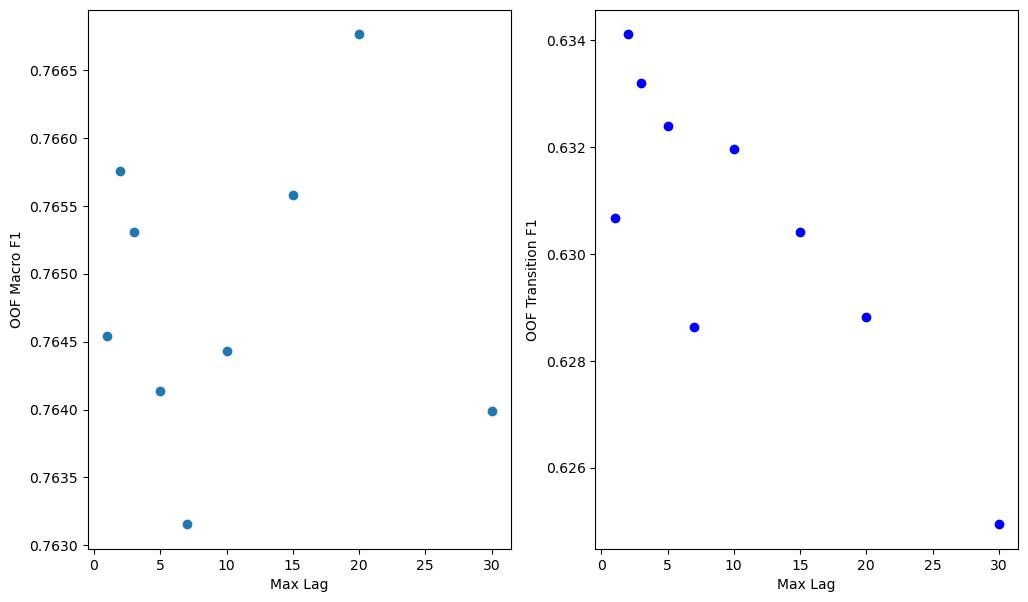

In [17]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 7),
)

ax1.scatter(lag_config_results["Max Lag"], lag_config_results["Average OOF Macro F1"])
ax1.set_ylabel("OOF Macro F1")
ax1.set_xlabel("Max Lag")

ax2.scatter(lag_config_results["Max Lag"], lag_config_results["Average OOF Transition F1"], c="b", label="Average Transition F1")
ax2.set_ylabel("OOF Transition F1")
ax2.set_xlabel("Max Lag")

plt.show()

The cross-validated results suggest that increasing temporal history does not uniformly improve classification performance. Macro F1 exhibits a shallow optimum at approximately 20 lags, whereas transition F1 is maximized using a much shorter history of two lags. Since identifying the transition state is more important, a lag configuration of [1, 2] will be selected.

In [ ]:
optimal_lags = [1, 2]

## 2. Training and Evaluation

Without lagged features

In [ ]:
result_unlagged_train_df, result_unlagged_test_df = pipeline(StationName, label_map, n_splits, train_size)

With lagged features

In [ ]:
result_lagged_train_df, result_lagged_test_df = pipeline(StationName, label_map, n_splits, train_size, True, lags_test)

## 3. Results

### 3.1 Without Lagged Features

#### Train

In [ ]:
result_unlagged_train_df

#### Test

In [ ]:
result_unlagged_test_df

### 3.2 With Lagged Features

#### Train

In [ ]:
result_lagged_train_df

#### Test

In [ ]:
result_lagged_test_df

### 3.3 Difference in Scores

Show the scores for lagged - unlagged, with positive scores indicating better performance with lagged features.

#### Train

In [ ]:
train_diff = result_lagged_train_df.copy()
float_cols = ["Average Macro F1", "Average Transition F1"]
train_diff[float_cols] = result_lagged_train_df[float_cols] - result_unlagged_train_df[float_cols]
train_diff = train_diff.rename(columns={
    "Average Macro F1": "Average Macro F1 Difference",
    "Average Transition F1": "Average Transition F1 Difference",
})

train_diff

#### Test

In [ ]:
test_diff = result_lagged_test_df.copy()
float_cols = ["Macro F1", "Transition F1"]
test_diff[float_cols] = result_lagged_test_df[float_cols] - result_unlagged_test_df[float_cols]
test_diff = test_diff.rename(columns={
    "Macro F1": "Macro F1 Difference",
    "Transition F1": "Transition F1 Difference",
})

test_diff

## 4. Statistical Analysis